In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv(r'F:\main\carrer\customer churn\project\raw_churn_data.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (10000, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,TechSupport,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,MonthlyCharges_x_MTM,Tenure_x_Security,MTM_x_NoSecurity,CostPerTenureMonth,Churn
0,Male,0,Yes,No,7.0,Yes,Yes,No,Yes,No,Month-to-month,No,Bank transfer,75.38,548.95,75.38,7.0,0.0,9.422500,1
1,Female,0,Yes,No,25.0,Yes,No phone service,Fiber optic,No internet service,Yes,Month-to-month,No,Credit card,27.90,671.39,27.90,0.0,1.0,1.073077,0
2,Female,0,No,Yes,51.0,Yes,Yes,Fiber optic,Yes,No internet service,Month-to-month,Yes,Mailed check,92.36,4721.52,92.36,51.0,0.0,1.776154,0
3,Male,0,Yes,Yes,30.0,Yes,No phone service,DSL,No internet service,No internet service,Month-to-month,Yes,Bank transfer,47.24,1417.39,47.24,0.0,1.0,1.523871,0
4,Male,0,Yes,No,12.0,Yes,Yes,Fiber optic,Yes,Yes,Month-to-month,No,Bank transfer,113.84,1413.45,113.84,12.0,0.0,8.756923,0


In [5]:
# Data types and missing values
print("Data Types:")
print(df.dtypes)
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nChurn Rate: {df['Churn'].mean():.2%}")

Data Types:
gender                   object
SeniorCitizen             int64
Partner                  object
Dependents               object
tenure                  float64
PhoneService             object
MultipleLines            object
InternetService          object
OnlineSecurity           object
TechSupport              object
Contract                 object
PaperlessBilling         object
PaymentMethod            object
MonthlyCharges          float64
TotalCharges            float64
MonthlyCharges_x_MTM    float64
Tenure_x_Security       float64
MTM_x_NoSecurity        float64
CostPerTenureMonth      float64
Churn                     int64
dtype: object

Missing Values:
gender                    0
SeniorCitizen             0
Partner                   0
Dependents                0
tenure                    0
PhoneService              0
MultipleLines             0
InternetService           0
OnlineSecurity            0
TechSupport               0
Contract                  0
Paperless

In [6]:
# Describe numeric columns
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'MonthlyCharges_x_MTM', 'Tenure_x_Security']
df[numeric_cols].describe()

,tenure,MonthlyCharges,TotalCharges,MonthlyCharges_x_MTM,Tenure_x_Security
count,10000.000000,9800.000000,9800.000000,10000.000000,10000.000000
mean,35.757600,67.885760,2413.493313,36.750721,11.649000
std,20.489344,29.064284,1815.865995,39.841562,20.468984
min,1.000000,18.010000,0.000000,0.000000,0.000000
25%,18.000000,42.750000,947.702500,0.000000,0.000000
50%,36.000000,68.080000,1978.150000,25.720000,0.000000
75%,53.000000,93.382500,3532.432500,71.380000,16.000000
max,71.000000,117.980000,8228.210000,117.960000,71.000000


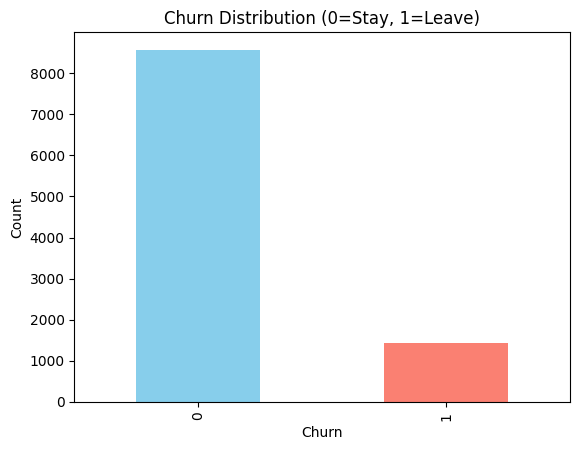

In [7]:
# Plot churn distribution
df['Churn'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Churn Distribution (0=Stay, 1=Leave)')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

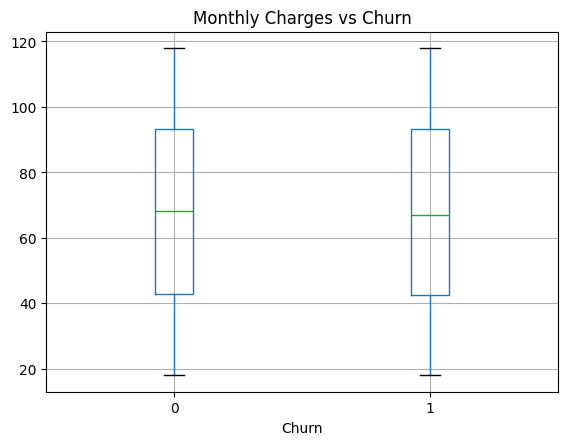

In [8]:
# Box plot of monthly charges vs churn
df.boxplot(column='MonthlyCharges', by='Churn')
plt.title('Monthly Charges vs Churn')
plt.suptitle('')  # Remove default title
plt.show()

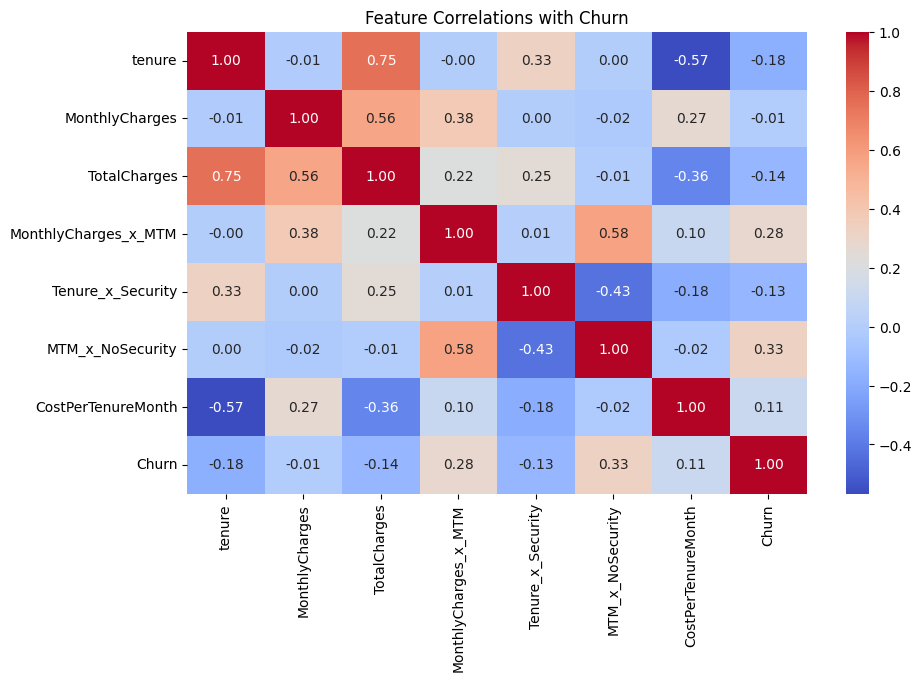

In [9]:
# Correlation heatmap
plt.figure(figsize=(10, 6))
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'MonthlyCharges_x_MTM', 'Tenure_x_Security', 'MTM_x_NoSecurity', 'CostPerTenureMonth', 'Churn']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlations with Churn')
plt.show()